In [38]:
import kagglehub
import pandas as pd
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

In [ ]:
path = kagglehub.dataset_download("taweilo/loan-approval-classification-data")
print("Path to dataset files:", path)

In [3]:
print(os.listdir("/root/.cache/kagglehub/datasets/taweilo/loan-approval-classification-data/versions/1"))

['loan_data.csv']


In [6]:
df = pd.read_csv("/root/.cache/kagglehub/datasets/taweilo/loan-approval-classification-data/versions/1/loan_data.csv")

df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [7]:
df.shape

(45000, 14)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [25]:
df.describe(include="all")

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
count,45000.000000,45000,45000,4.500000e+04,45000.000000,45000,45000.000000,45000,45000.000000,45000.000000,45000.000000,45000.000000,45000,45000.000000
unique,NaN,2,5,NaN,NaN,4,NaN,6,NaN,NaN,NaN,NaN,2,NaN
top,NaN,male,Bachelor,NaN,NaN,RENT,NaN,EDUCATION,NaN,NaN,NaN,NaN,Yes,NaN
freq,NaN,24841,13399,NaN,NaN,23443,NaN,9153,NaN,NaN,NaN,NaN,22858,NaN
mean,27.748156,NaN,NaN,8.031905e+04,5.390156,NaN,9583.157556,NaN,11.006606,0.139725,5.867489,632.608756,NaN,0.222222
std,5.909318,NaN,NaN,8.042250e+04,5.905545,NaN,6314.886691,NaN,2.978808,0.087212,3.879702,50.435865,NaN,0.415744
min,20.000000,NaN,NaN,8.000000e+03,0.000000,NaN,500.000000,NaN,5.420000,0.000000,2.000000,390.000000,NaN,0.000000
25%,24.000000,NaN,NaN,4.720400e+04,1.000000,NaN,5000.000000,NaN,8.590000,0.070000,3.000000,601.000000,NaN,0.000000
50%,26.000000,NaN,NaN,6.704800e+04,4.000000,NaN,8000.000000,NaN,11.010000,0.120000,4.000000,640.000000,NaN,0.000000
75%,30.000000,NaN,NaN,9.578925e+04,8.000000,NaN,12237.250000,NaN,12.990000,0.190000,8.000000,670.000000,NaN,0.000000


In [24]:
age_median = df[df['person_age'] <= 100]['person_age'].median()
emp_exp_median = df[df['person_emp_exp'] <= 60]['person_emp_exp'].median()

df.loc[df['person_age'] > 100, 'person_age'] = age_median
df.loc[df['person_emp_exp'] > 60, 'person_emp_exp'] = emp_exp_median

In [11]:
print(df.isnull().sum())

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


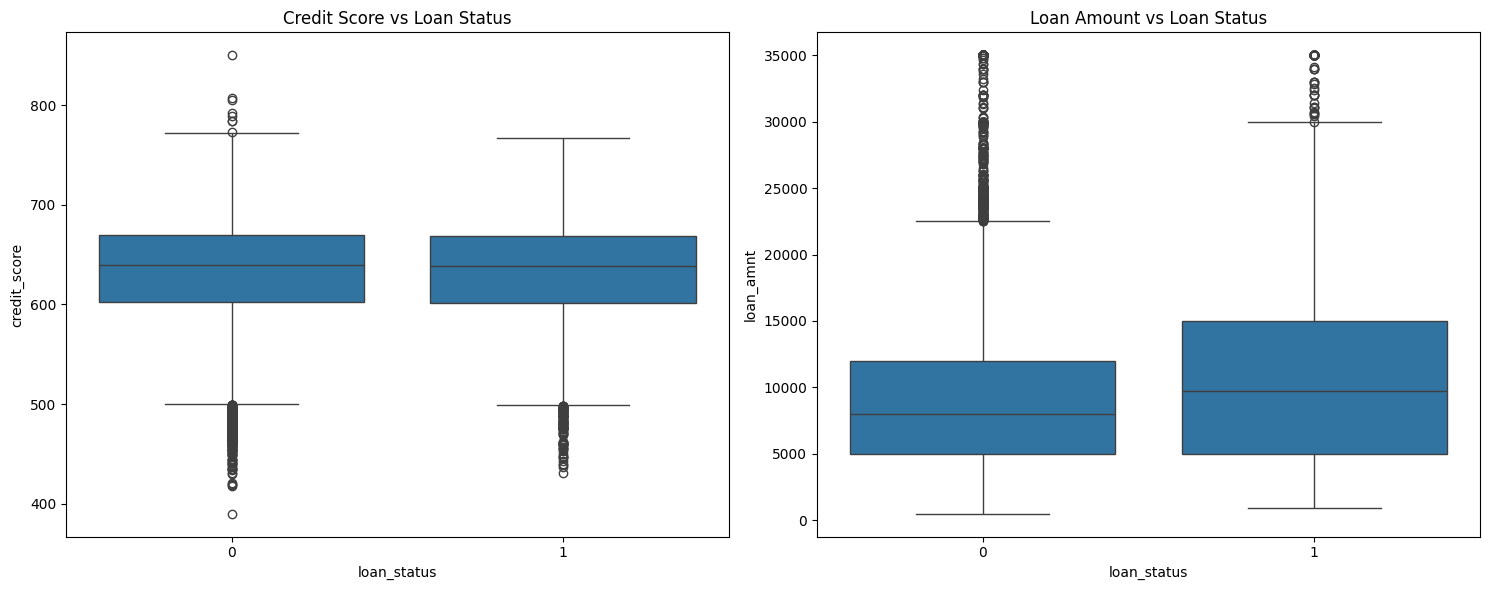

In [12]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left
sns.boxplot(data = df, x = "loan_status", y = "credit_score", ax = axes[0]),
palette = 'Set2'
axes[0].set_title("Credit Score vs Loan Status")

# Right
sns.boxplot(data = df, x = "loan_status", y = "loan_amnt", ax = axes[1]),
palette = 'Set2'
axes[1].set_title("Loan Amount vs Loan Status")
plt.tight_layout()
plt.show()

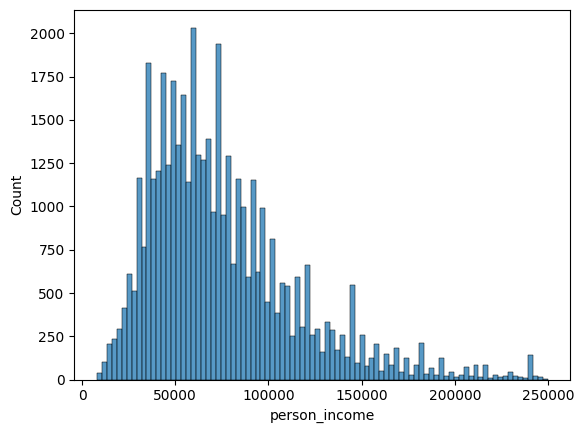

In [18]:
sns.histplot(data = df[df['person_income'] < 250000], x = 'person_income')
plt.show()

/tmp/ipykernel_7819/2998129659.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df[df['person_income'] < 200000],
/tmp/ipykernel_7819/2998129659.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'loan_status', y = 'loan_percent_income',


Text(0.5, 1.0, 'Previous Defaults vs Loan Status')

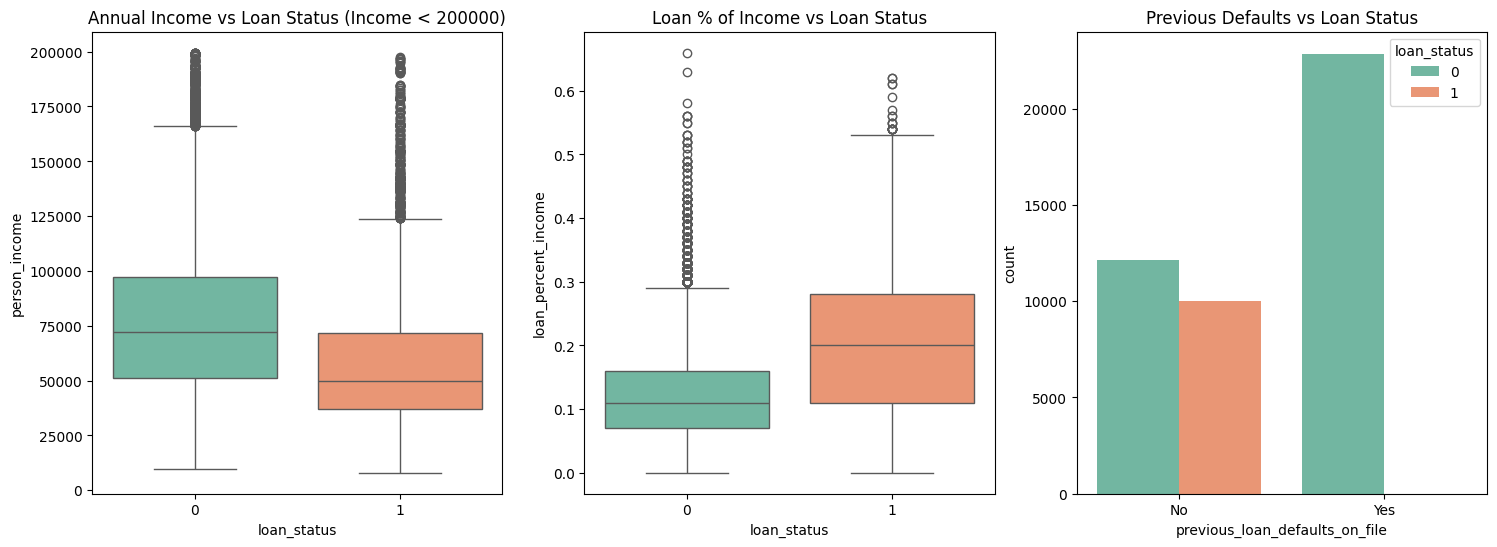

In [23]:
fig, axes = plt.subplots(1, 3, figsize = (18, 6))

# 1. Income
sns.boxplot(data = df[df['person_income'] < 200000], 
x = 'loan_status', 
y = 'person_income',
ax = axes[0], 
palette = 'Set2')
axes[0].set_title('Annual Income vs Loan Status (Income < 200000)')

# 2. Loan Percent Income
sns.boxplot(data = df, x = 'loan_status', y = 'loan_percent_income',
ax = axes[1], palette = 'Set2')
axes[1].set_title('Loan % of Income vs Loan Status')

# 3. Previous Defaults (Category)
sns.countplot(data = df, x = 'previous_loan_defaults_on_file', hue = 'loan_status',
ax = axes[2], palette = 'Set2')
axes[2].set_title("Previous Defaults vs Loan Status")

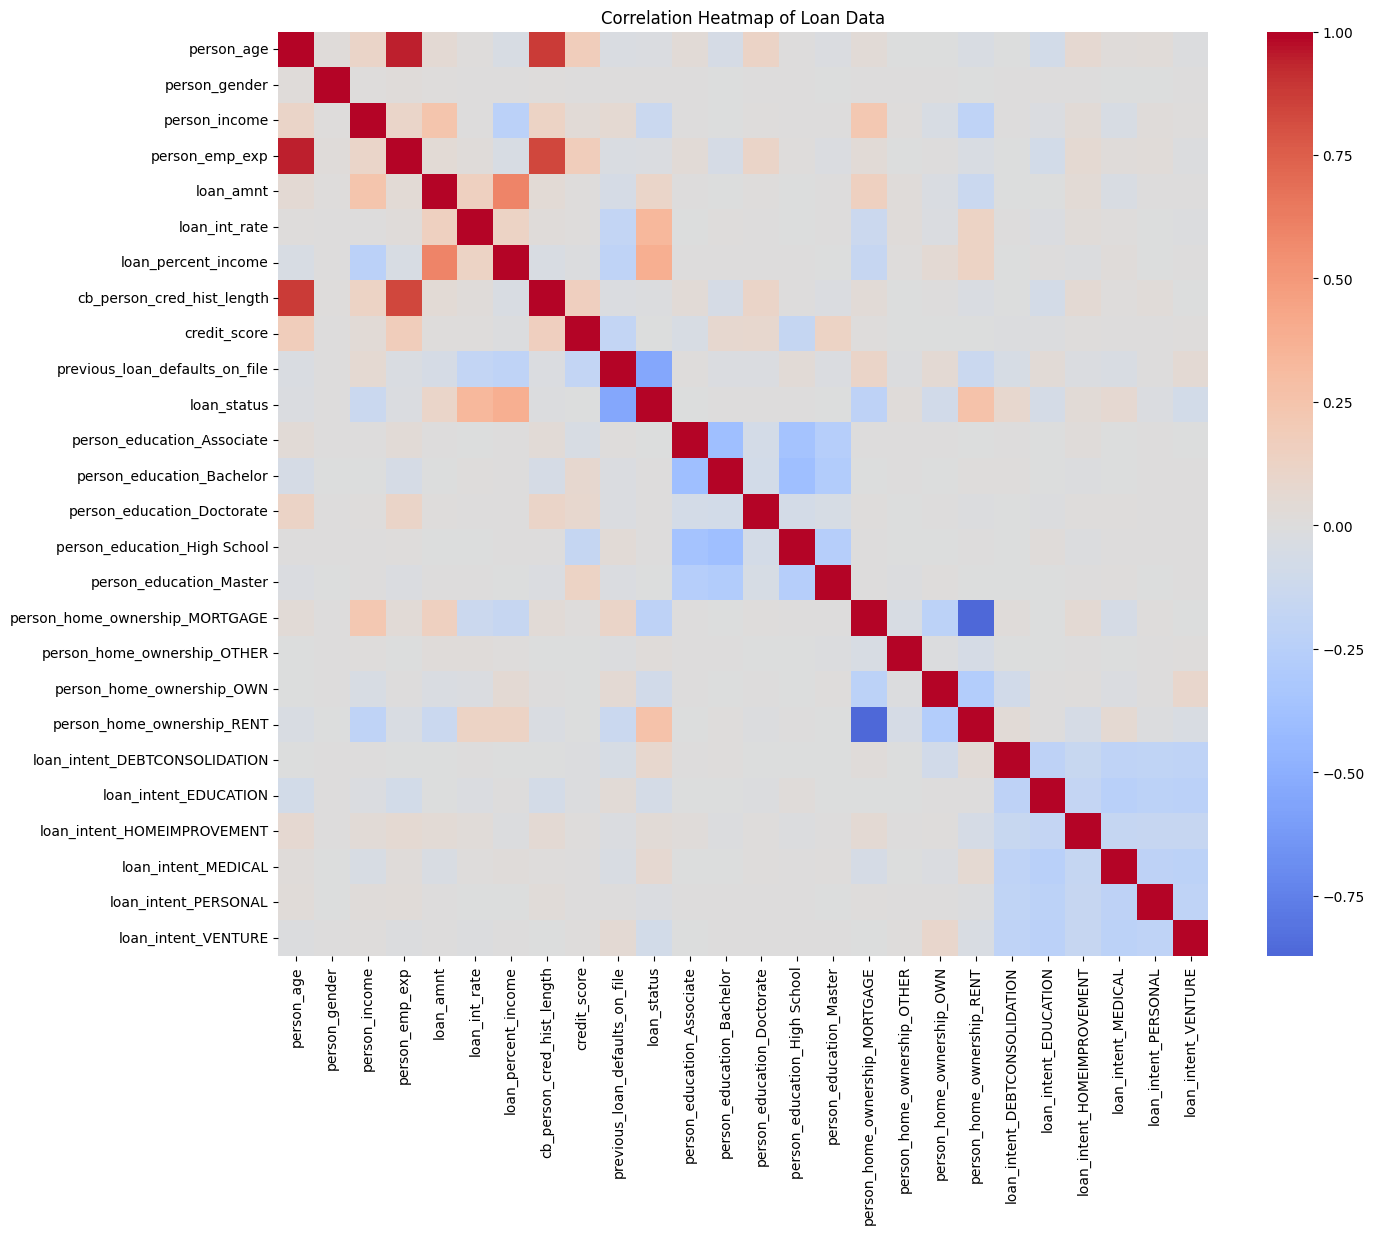


Loan Approval Influence Ranking
loan_status                       1.000000
loan_percent_income               0.384880
loan_int_rate                     0.332005
person_home_ownership_RENT        0.255239
loan_amnt                         0.107714
loan_intent_DEBTCONSOLIDATION     0.084130
loan_intent_MEDICAL               0.065195
loan_intent_HOMEIMPROVEMENT       0.033838
person_home_ownership_OTHER       0.013645
person_education_Bachelor         0.004728
person_education_Doctorate        0.001833
person_education_High School      0.001277
person_gender                    -0.000561
person_education_Associate       -0.002765
person_education_Master          -0.004741
credit_score                     -0.007647
cb_person_cred_hist_length       -0.014851
person_emp_exp                   -0.019203
person_age                       -0.020520
loan_intent_PERSONAL             -0.022488
loan_intent_EDUCATION            -0.064006
loan_intent_VENTURE              -0.085992
person_home_ownership

In [26]:
# Encoding

# Binary
df['person_gender'] = df['person_gender'].map({'male': 1, 'female': 0})
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'Yes': 1, 'No': 0})

# One-Hot
df_encoded = pd.get_dummies(df)

# Correlation Heatmap
corr_matrix = df_encoded.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot = False, cmap = 'coolwarm', center = 0)
plt.title('Correlation Heatmap of Loan Data')
plt.show()

# Loan_Status Coefficient Ranking
status_corr = corr_matrix['loan_status'].sort_values(ascending = False)
print("\nLoan Approval Influence Ranking")
print(status_corr)

In [34]:
# Feature Engineering

# 1. Loan-to-Income Ration: Measures the debt burden to income
df['loan_to_income'] = df['loan_amnt'] / df['person_income']

# 2. Age-Employment Ratio: Observes professional stability relative to the applicant's age
df['age_emp_ratio'] = df['person_emp_exp'] / df['person_age']

# 3. Income per Age: Measures earning efficiency and identifies young high-earners
df['income_per_age'] = df['person_income'] / df['person_age']

# 4. Credit Load: Measures loan amount per credit score
df['credit_load'] = df['loan_amnt'] / df['credit_score']

# 5. Score-to-Income Ratio: Analyzes creditworthiness relative to income level
df['score_income_ratio'] = df['credit_score'] / df['person_income']

# 6. Interest Burden: Estimates the total interest scale the applicant is required to pay
df['interest_burden'] = df['loan_amnt'] * df['loan_int_rate']

# 7. Post-18 Work Ratio: Calculates the percentage of adult life spent employed
df['exp_per_age'] = df['person_emp_exp'] / (df['person_age'] - 18).replace(0, 1)

# 8. Monthly Income: Breaks down annual income to simulate monthly cash flow
df['monthly_income'] = df['person_income'] / 12

# 9. High-Risk Flag: Combines 'Previous Default' and 'High Debt-to-Income (>30%)' as a critical risk factor
df['high_risk_flag'] = ((df['previous_loan_defaults_on_file'] == 1) & (df['loan_percent_income'] > 0.3)).astype(int)

# 10. Low-Score High-Loan Flag: Flags 'Low Credit Score (<600)' combined with 'Large Loan Amount (>10k)'
df['low_score_high_loan'] = ((df['credit_score'] < 600) & (df['loan_amnt'] > 10000)).astype(int)

# Encoding
df_final = pd.get_dummies(df)

In [35]:
# Training/Testing Split
X = df_final.drop('loan_status', axis = 1)
y = df_final['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

print(f"Train set samples: {len(X_train)}")
print(f"Test set samples: {len(X_test)}")

Train set samples: 36000
Test set samples: 9000


In [36]:
scaler = StandardScaler()

num_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
            'credit_score', 'loan_to_income', 'age_emp_ratio', 'income_per_age', 
            'credit_load', 'score_income_ratio', 'interest_burden', 'exp_per_age', 'monthly_income']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [41]:
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth = 10, random_state = 42),
    "Random Forest": RandomForestClassifier(n_estimators = 100, random_state = 42),
    "XGBoost": XGBClassifier(n_estimators = 100, learning_rate = 0.1, random_state = 42)
}
results = {}

for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    probs = clf.predict_proba(X_test_scaled)[:, 1]

    roc_auc = roc_auc_score(y_test, probs)
    pr_roc = average_precision_score(y_test, probs)

    results[name] = {"ROC AUC": roc_auc, "PR AUC": pr_roc, "probs": probs}
    print(f"{name} Complete Training")

print("\nModel Performance Ranking")
for name, metrics in results.items():
    print(f"{name}: ROC AUC = {metrics['ROC AUC']:.4f}, PR AUC = {metrics['PR AUC']:.4f}")

Decision Tree Complete Training
Random Forest Complete Training
XGBoost Complete Training

Model Performance Ranking
Decision Tree: ROC AUC = 0.9649, PR AUC = 0.8957
Random Forest: ROC AUC = 0.9761, PR AUC = 0.9358
XGBoost: ROC AUC = 0.9776, PR AUC = 0.9383


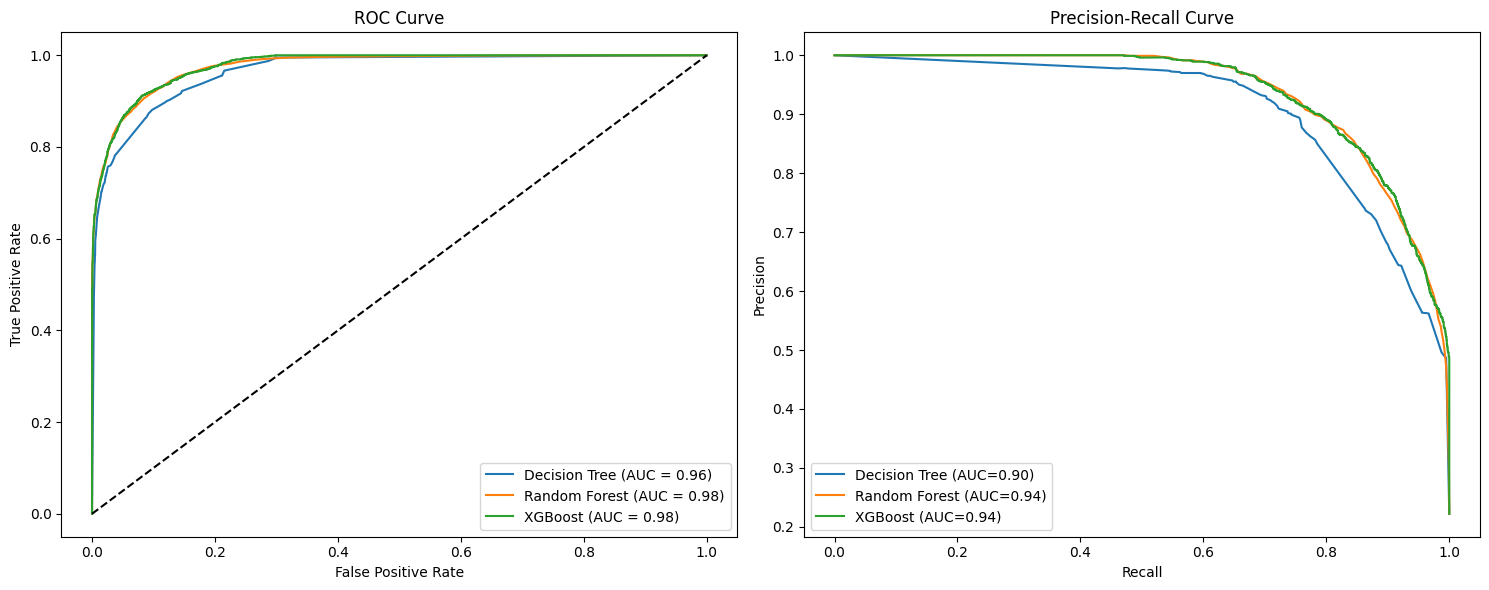

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve
plt.figure(figsize=(15, 6))

# ROC Curve
plt.subplot(1, 2, 1)
for name, m in results.items():
    fpr, tpr, _ = roc_curve(y_test, m['probs'])
    plt.plot(fpr, tpr, label = f"{name} (AUC = {m['ROC AUC']:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.subplot(1, 2, 2)
for name, m in results.items():
    prec, rec, _ = precision_recall_curve(y_test, m['probs'])
    plt.plot(rec, prec, label=f"{name} (AUC={m['PR AUC']:.2f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()

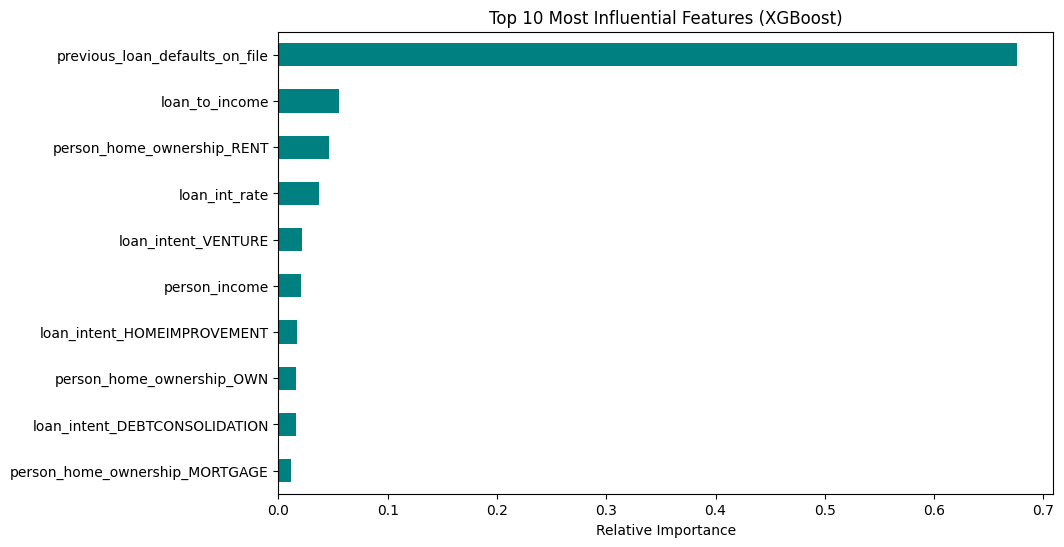

In [49]:
# 1. Get the feature importance from the trained XGBoost model
# Assuming 'XGBoost' is the key in your results/models
best_model = models['XGBoost']
feat_importances = pd.Series(best_model.feature_importances_, index=X.columns)

# 2. Plot the Top 10
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title('Top 10 Most Influential Features (XGBoost)')
plt.xlabel('Relative Importance')
plt.show()

Best F1: 0.37
Highest F1-Score: 0.8488


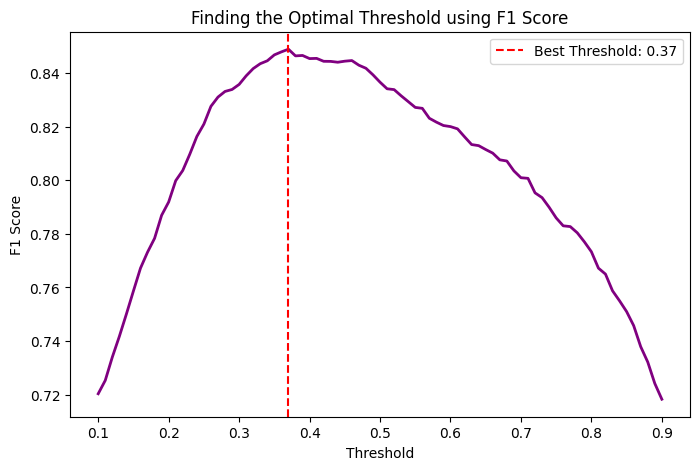

In [54]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = [f1_score(y_test, (results['XGBoost']['probs'] >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best F1: {best_threshold:.2f}")
print(f"Highest F1-Score: {max(f1_scores):.4f}")

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, color='purple', lw=2)
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold: {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Finding the Optimal Threshold using F1 Score')
plt.legend()
plt.show()

 Classification Report (Threshold = 0.37) 
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      7000
           1       0.84      0.85      0.85      2000

    accuracy                           0.93      9000
   macro avg       0.90      0.90      0.90      9000
weighted avg       0.93      0.93      0.93      9000



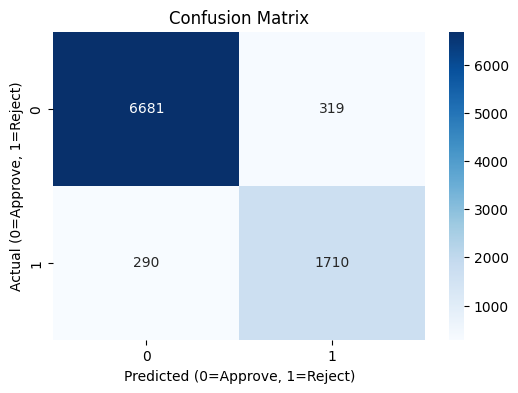

In [56]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

custom_threshold = 0.37
y_pred_custom = (results['XGBoost']['probs'] >= custom_threshold).astype(int)


print(" Classification Report (Threshold = 0.37) ")
print(classification_report(y_test, y_pred_custom))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_custom), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted (0=Approve, 1=Reject)')
plt.ylabel('Actual (0=Approve, 1=Reject)')
plt.title('Confusion Matrix')
plt.show()